# NHANES Exploratory Data Analysis

This notebook performs exploratory data analysis on the prepared NHANES analysis dataset.

The data preparation, cleaning, feature engineering, and study-population selection was completed separately in [`nhanes_data_preparation.ipynb`](nhanes_data_preparation.ipynb) notebook.

The analysis population includes adults age 20 years or older with a valid HbA1c measurement who reported no previous diabetes diagnosis.

### Loading and Verify the Analysis Dataset

In [497]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [498]:
data_path = Path("../data/nhanes_analysis_ready.parquet")

print("Data file:", data_path)
print("File exists:", data_path.exists())

Data file: ..\data\nhanes_analysis_ready.parquet
File exists: True


In [499]:
analysis_data = pd.read_parquet(data_path)
analysis_data.head()

,SEQN,age,sex,race_ethnicity,education,income_poverty_ratio,mec_weight,psu,stratum,cycle,...,vigorous_minutes_week,moderate_minutes_week,recreational_activity_minutes_week,smoked_100_cigarettes,current_smoking,sleep_hours,hypertension,high_cholesterol,elevated_hba1c,smoking_status
0,62161.0,22.0,1.0,3.0,3.0,3.15,104236.582554,1.0,91.0,2011-2012,...,0.0,0.0,0.0,2.0,NaN,8.0,2.0,2.0,0,Never
1,62164.0,44.0,2.0,3.0,4.0,1.67,127965.226204,1.0,94.0,2011-2012,...,300.0,45.0,345.0,2.0,NaN,8.0,2.0,2.0,0,Never
2,62169.0,21.0,1.0,6.0,3.0,0.33,14783.600953,1.0,92.0,2011-2012,...,0.0,0.0,0.0,2.0,NaN,8.0,2.0,2.0,0,Never
3,62172.0,43.0,2.0,4.0,3.0,2.02,27122.911908,2.0,96.0,2011-2012,...,0.0,0.0,0.0,1.0,1.0,8.0,2.0,2.0,0,Current
4,62174.0,80.0,1.0,3.0,5.0,4.30,27335.895242,3.0,90.0,2011-2012,...,0.0,0.0,0.0,2.0,NaN,9.0,1.0,1.0,0,Never


In [500]:
# Verifying dataset dimensions and participant IDs
print("Rows:", analysis_data.shape[0])
print("Columns:", analysis_data.shape[1])

print("Unique SEQN:", analysis_data["SEQN"].nunique())
print("Duplicate SEQN:", analysis_data["SEQN"].duplicated().sum())

Rows: 17156
Columns: 32
Unique SEQN: 17156
Duplicate SEQN: 0


In [501]:
#column names and data types
analysis_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17156 entries, 0 to 17155
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   SEQN                                17156 non-null  float64
 1   age                                 17156 non-null  float64
 2   sex                                 17156 non-null  float64
 3   race_ethnicity                      17156 non-null  float64
 4   education                           17143 non-null  float64
 5   income_poverty_ratio                15527 non-null  float64
 6   mec_weight                          17156 non-null  float64
 7   psu                                 17156 non-null  float64
 8   stratum                             17156 non-null  float64
 9   cycle                               17156 non-null  object 
 10  hba1c                               17156 non-null  float64
 11  bmi                                 16963

#### HbA1c Distribution and Target Definition

Participants were grouped into three HbA1c ranges to show where values fall within the study population:

- Below 5.7%
- 5.7% to 6.4%
- 6.5% or higher

The table below reports the number and percentage of participants in each range.

In [503]:
hba1c_ranges = pd.cut(
    analysis_data["hba1c"],
    bins=[-np.inf, 5.7, 6.5, np.inf],
    right=False,
    labels=[
        "Below 5.7%",
        "5.7%–6.4%",
        "6.5% or higher"
    ]
)

hba1c_range_table = (
    hba1c_ranges
    .value_counts()
    .sort_index()
    .to_frame("count")
)

hba1c_range_table["percent"] = (
    hba1c_range_table["count"]
    / len(analysis_data)
    * 100
).round(2)

hba1c_range_table

,count,percent
hba1c,,
Below 5.7%,11693,68.16
5.7%–6.4%,4926,28.71
6.5% or higher,537,3.13


In [504]:
analysis_data["hba1c"].describe()

count    17156.000000
mean         5.515511
std          0.599146
min          3.600000
25%          5.200000
50%          5.500000
75%          5.700000
max         14.300000
Name: hba1c, dtype: float64

HbA1c values ranged from 3.6% to 14.3%, with a mean of 5.52% and a median of 5.50%.

The middle 50% of participants had HbA1c values between 5.2% and 5.7%. The 75th percentile was 5.7%, which corresponds to the threshold used to define the elevated HbA1c target.

Although most participants had HbA1c values near the normal range, the maximum value of 14.3% indicates that some adults who reported no previous diabetes diagnosis had substantially elevated laboratory HbA1c measurements.

The machine-learning target is `elevated_hba1c`.

- `0` = HbA1c below 5.7%
- `1` = HbA1c at or above 5.7%

The original laboratory HbA1c variable (`hba1c`) is used only to define the target and will not be included as a model predictor.

**Dataset Verification**

The prepared dataset contains one row per participant. Participant IDs are unique, indicating that the merging process did not create duplicate observations.

The dataset will now be examined for missing values, variable distributions, potential outliers, and relationships with the elevated HbA1c target.


In [507]:
target_summary = (
    analysis_data["elevated_hba1c"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

target_summary["percent"] = (
    target_summary["count"]
    / len(analysis_data)
    * 100
).round(2)

target_summary.index = [
    "Normal HbA1c",
    "Elevated HbA1c"
]

target_summary

,count,percent
Normal HbA1c,11693,68.16
Elevated HbA1c,5463,31.84


The target distribution is moderately imbalanced, with approximately 68% of participants classified as normal and 32% classified as having elevated HbA1c.

Because of this imbalance, later machine-learning evaluation will consider recall, precision, F1-score, ROC-AUC, and PR-AUC in addition to accuracy.

### Missing Data Assessment

Missing values are examined before modeling to understand which variables may require preprocessing.

Some questionnaire variables contain high missingness because of NHANES skip patterns. For example, participants reporting no recreational activity were not asked follow-up questions about activity duration and frequency.

Missing values will not be imputed during EDA. Imputation will be performed later within the machine-learning preprocessing pipeline to avoid data leakage.

In [510]:
missing_summary = pd.DataFrame({
    "missing_count": analysis_data.isna().sum(),
    "missing_percent": (
        analysis_data.isna().mean() * 100
    ).round(2)
})

missing_summary = (
    missing_summary
    .sort_values(
        "missing_percent",
        ascending=False
    )
)

missing_summary[
    missing_summary["missing_count"] > 0
]

,missing_count,missing_percent
vigorous_minutes,12786,74.53
vigorous_days,12777,74.48
current_smoking,10054,58.60
moderate_minutes,9891,57.65
moderate_days,9875,57.56
income_poverty_ratio,1629,9.50
waist_cm,816,4.76
bmi,193,1.12
weight_kg,166,0.97
sedentary_minutes,109,0.64


Several raw questionnaire variables contain substantial missingness because of NHANES skip patterns.

The derived weekly activity variables are much more complete because participants reporting no activity were assigned zero activity where appropriate.

Similarly, the derived `smoking_status` variable combines smoking questionnaire responses into Never, Former, and Current categories and has very little remaining missingness.

Among the candidate modeling predictors, `income_poverty_ratio` and `waist_cm` contain the most notable remaining missingness. Missing values will be handled during machine-learning preprocessing rather than by deleting participants during EDA.

### Continuous Variable Exploration

**Distributions and Summary Statistics**

Continuous predictors are examined to understand their distributions, central tendency, variability, missingness, and skewness.

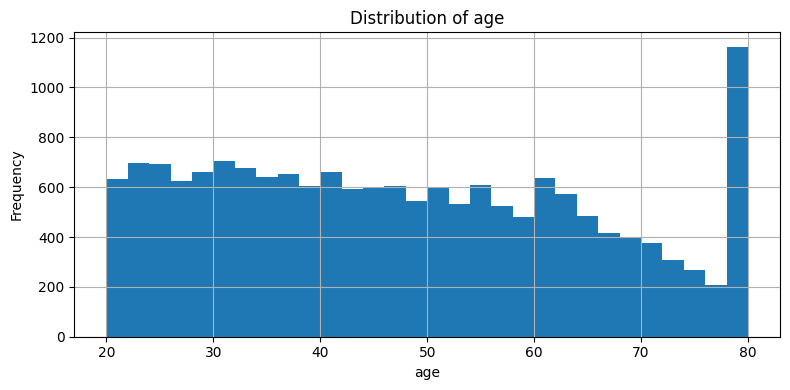

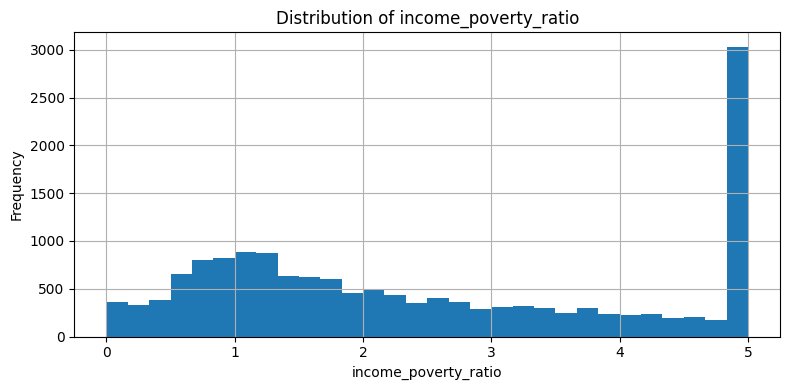

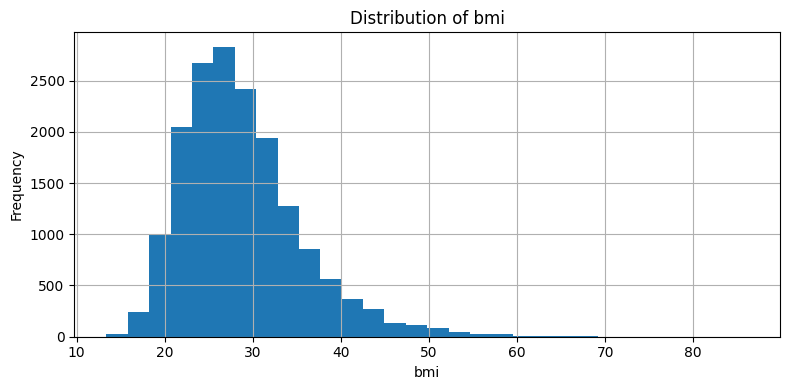

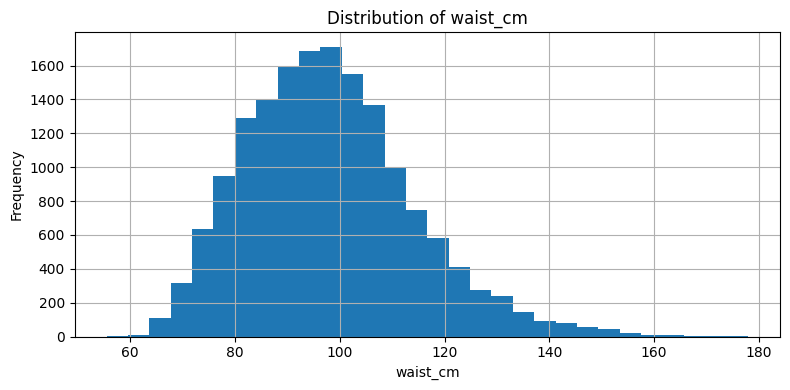

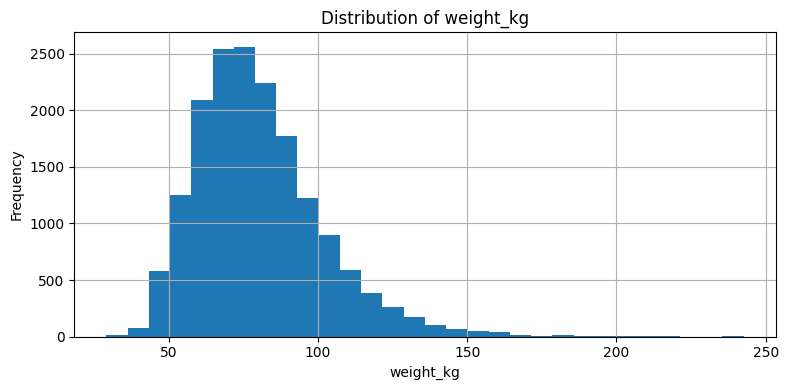

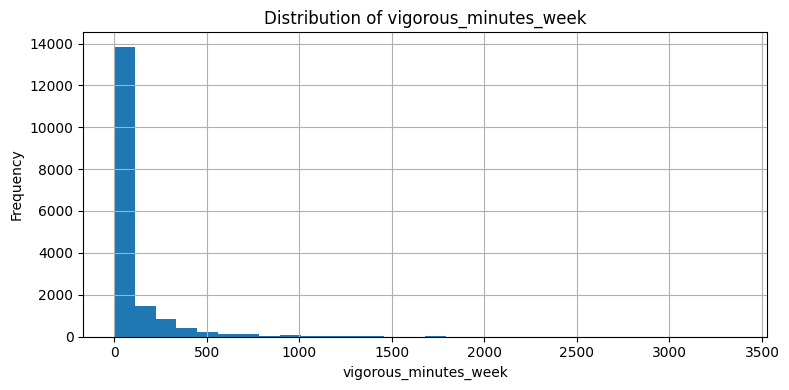

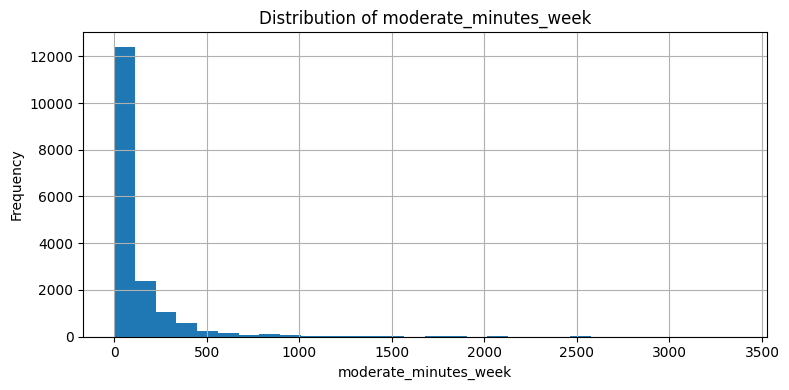

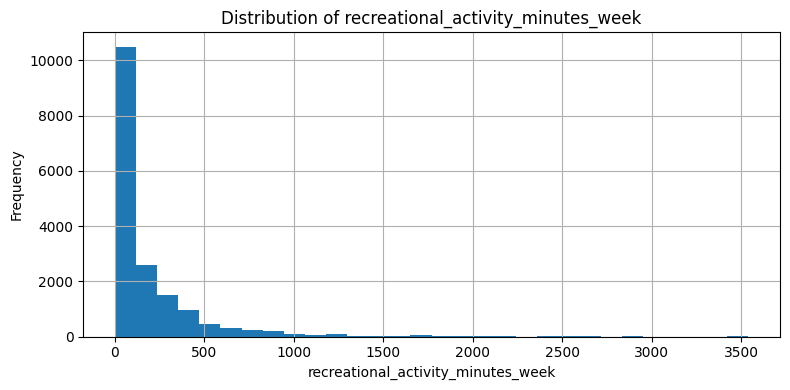

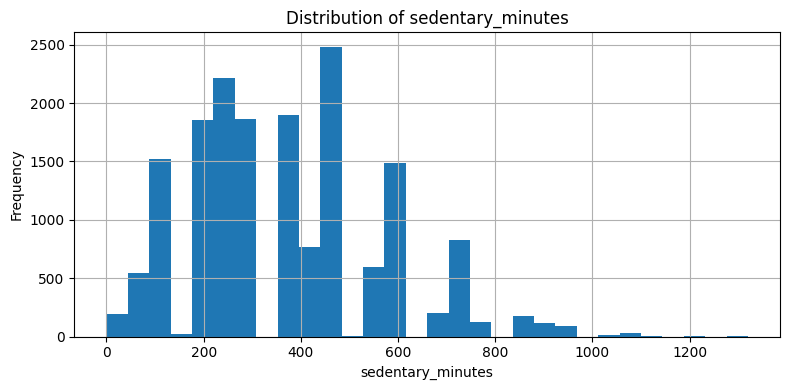

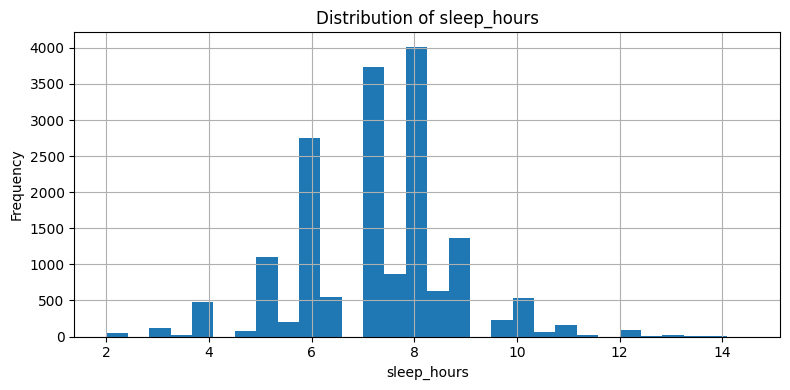

In [513]:
continuous_features = [
    "age",
    "income_poverty_ratio",
    "bmi",
    "waist_cm",
    "weight_kg",
    "vigorous_minutes_week",
    "moderate_minutes_week",
    "recreational_activity_minutes_week",
    "sedentary_minutes",
    "sleep_hours"
]
# Histograms
for column in continuous_features:

    plt.figure(figsize=(8, 4))

    analysis_data[column].dropna().hist(
        bins=30
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [514]:
# Continuous-variable summary
continuous_summary = (
    analysis_data[continuous_features]
    .describe()
    .T
)

continuous_summary["missing_count"] = (
    analysis_data[continuous_features]
    .isna()
    .sum()
)

continuous_summary["missing_percent"] = (
    analysis_data[continuous_features]
    .isna()
    .mean()
    .mul(100)
    .round(2)
)

continuous_summary["skewness"] = (
    analysis_data[continuous_features]
    .skew()
)

continuous_summary.round(2)

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_percent,skewness
age,17156.0,47.42,17.49,20.0,32.00,46.00,61.00,80.0,0,0.00,0.25
income_poverty_ratio,15527.0,2.52,1.64,0.0,1.09,2.11,4.12,5.0,1629,9.50,0.33
bmi,16963.0,28.77,6.88,13.4,24.00,27.70,32.20,86.2,193,1.12,1.30
waist_cm,16340.0,97.94,16.09,55.5,86.40,96.60,107.40,177.9,816,4.76,0.64
weight_kg,16990.0,80.32,21.27,29.1,65.30,77.20,91.48,242.6,166,0.97,1.10
vigorous_minutes_week,17144.0,63.08,161.87,0.0,0.00,0.00,30.00,3360.0,12,0.07,4.96
moderate_minutes_week,17136.0,92.69,197.95,0.0,0.00,0.00,120.00,3360.0,20,0.12,5.27
recreational_activity_minutes_week,17131.0,155.79,281.06,0.0,0.00,20.00,210.00,3540.0,25,0.15,3.79
sedentary_minutes,17047.0,368.58,200.42,0.0,240.00,360.00,480.00,1320.0,109,0.64,0.61
sleep_hours,17096.0,7.24,1.53,2.0,6.00,7.00,8.00,14.5,60,0.35,0.06


Age, income-to-poverty ratio, sedentary time, and waist circumference showed relatively mild to moderate skewness.

BMI and body weight were more strongly right-skewed.

The recreational activity measures were highly right-skewed and contained many zero values because a substantial number of participants reported no vigorous or moderate recreational activity.

Sleep duration was approximately symmetric.

Because the activity variables are strongly skewed, both means and medians will be considered when comparing HbA1c groups.

**Outlier and Plausibility Checks**

Boxplots and the interquartile-range (IQR) rule are used to identify potentially unusual observations.

An observation identified by the IQR rule is not automatically considered an error. Extreme but plausible health or behavioral measurements will be retained unless there is evidence that they are invalid.

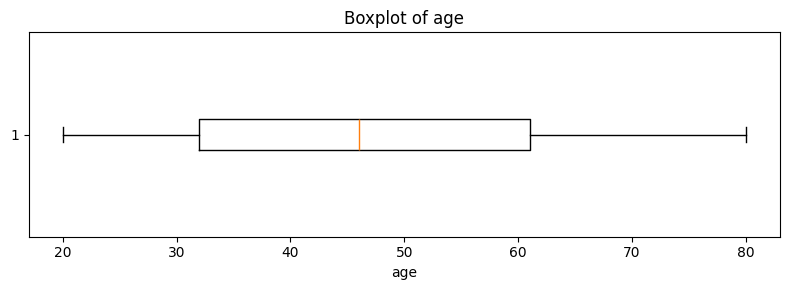

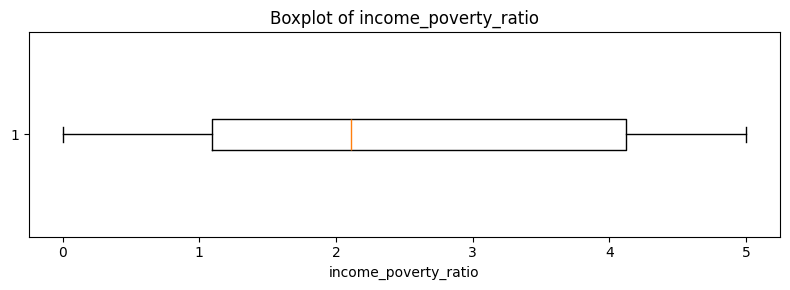

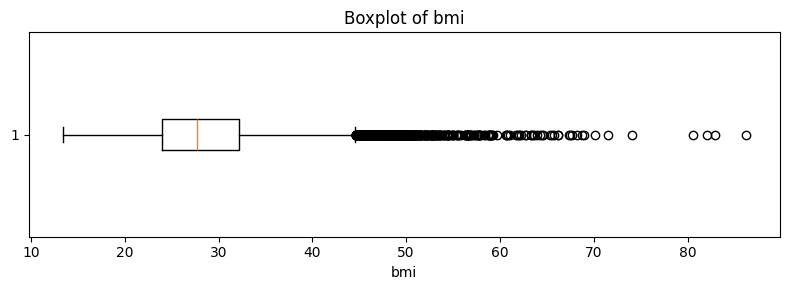

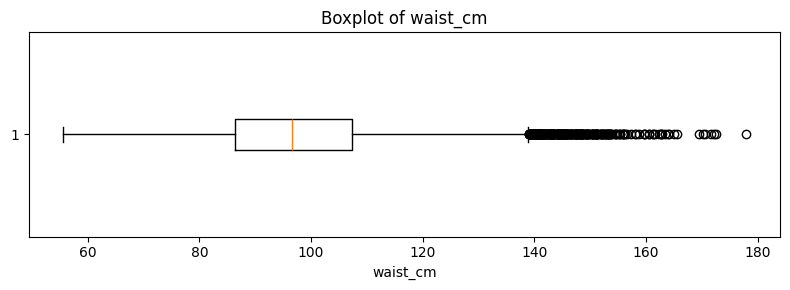

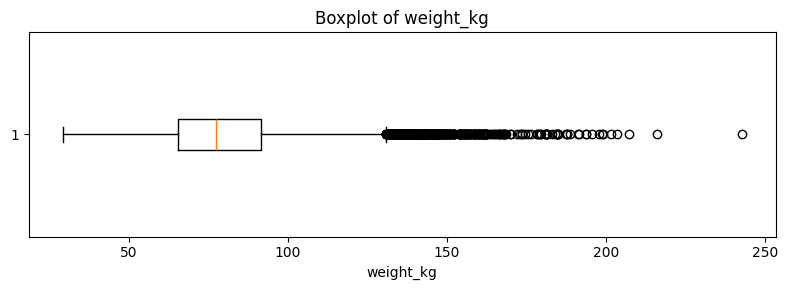

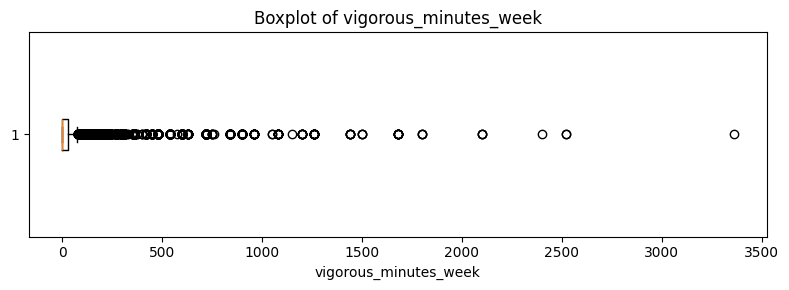

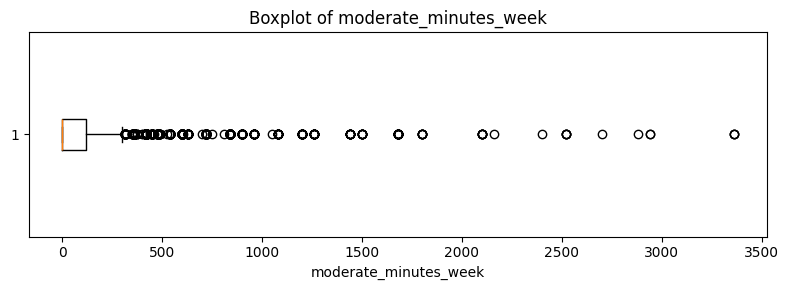

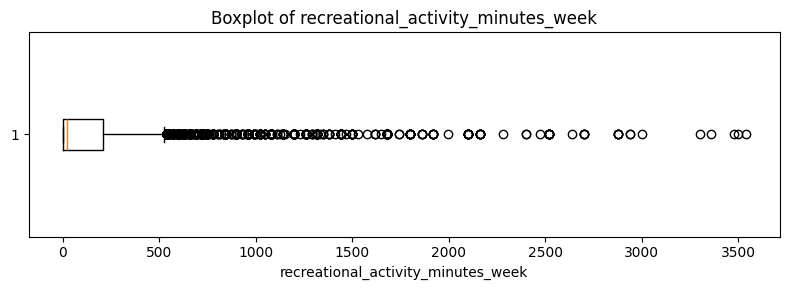

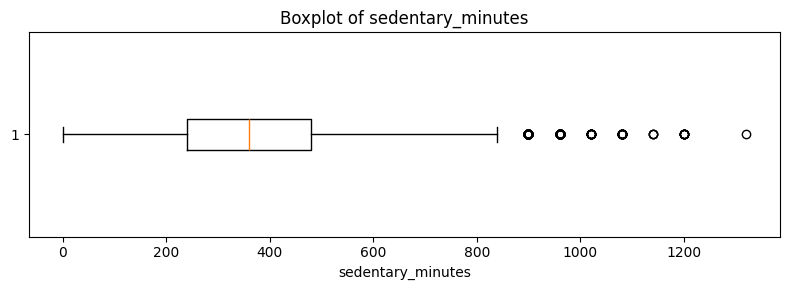

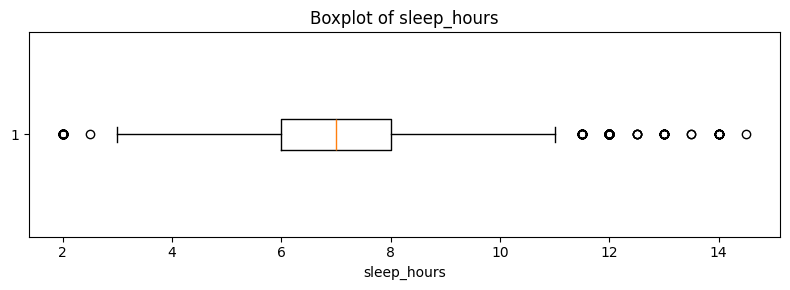

In [517]:
# Boxplots
for column in continuous_features:

    plt.figure(figsize=(8, 3))

    plt.boxplot(
        analysis_data[column].dropna(),
        vert=False
    )

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

In [518]:
# IQR-based potential outlier summary
outlier_summary = []

for column in continuous_features:

    series = analysis_data[column].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (series < lower_bound)
        | (series > upper_bound)
    ).sum()

    outlier_summary.append({
        "variable": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "potential_outliers": outlier_count,
        "outlier_percent": round(
            outlier_count / len(series) * 100,
            2
        )
    })

outlier_summary = pd.DataFrame(
    outlier_summary
)

outlier_summary.round(2)

,variable,Q1,Q3,IQR,lower_bound,upper_bound,potential_outliers,outlier_percent
0,age,32.00,61.00,29.00,-11.50,104.50,0,0.00
1,income_poverty_ratio,1.09,4.12,3.03,-3.46,8.66,0,0.00
2,bmi,24.00,32.20,8.20,11.70,44.50,506,2.98
3,waist_cm,86.40,107.40,21.00,54.90,138.90,277,1.70
4,weight_kg,65.30,91.48,26.17,26.04,130.74,440,2.59
5,vigorous_minutes_week,0.00,30.00,30.00,-45.00,75.00,3662,21.36
6,moderate_minutes_week,0.00,120.00,120.00,-180.00,300.00,1315,7.67
7,recreational_activity_minutes_week,0.00,210.00,210.00,-315.00,525.00,1345,7.85
8,sedentary_minutes,240.00,480.00,240.00,-120.00,840.00,261,1.53
9,sleep_hours,6.00,8.00,2.00,3.00,11.00,207,1.21


BMI, waist circumference, and body weight contain some high values, but these measurements may represent valid participants and are not automatically removed.

The IQR rule flags many recreational activity observations because these variables are highly right-skewed and contain many zeros. Therefore, the IQR rule is not an appropriate reason by itself to remove high activity values.

Sedentary time and sleep duration contain a small number of unusually high observations. A time-use plausibility check is performed below.

**Sedentary + Sleep Plausibility Check**

In [520]:
# Temporary EDA variable only
analysis_data["sedentary_plus_sleep"] = (
    analysis_data["sedentary_minutes"] / 60
    + analysis_data["sleep_hours"]
)

time_use_summary = []

for threshold in [24, 25, 26, 28, 30]:

    count = (
        analysis_data["sedentary_plus_sleep"]
        > threshold
    ).sum()

    percent = (
        count / len(analysis_data) * 100
    )

    time_use_summary.append({
        "threshold_hours": threshold,
        "participants": count,
        "percent": round(percent, 2)
    })

pd.DataFrame(time_use_summary)

,threshold_hours,participants,percent
0,24,47,0.27
1,25,25,0.15
2,26,12,0.07
3,28,2,0.01
4,30,1,0.01


Only a very small proportion of participants had combined reported sedentary time and sleep duration exceeding 24 hours per day.

Because these measures are self-reported and the inconsistency affects only a small portion of the analysis population, these observations will be retained rather than automatically removed.

The temporary `sedentary_plus_sleep` variable is used only for this EDA plausibility check and will not be included as a machine-learning predictor.

In [522]:
#removing the temp coloumn
analysis_data.drop(
    columns="sedentary_plus_sleep",
    inplace=True
)

### Categorical Variable Exploration

Categorical predictors are converted to readable labels for visualization and interpretation.The original coded variables are retained for later machine-learning preprocessing.

**Category Distributation**

In [524]:
# NHANES numeric codes converted to readable labels

sex_map = {
    1.0: "Male",
    2.0: "Female"
}

race_map = {
    1.0: "Mexican American",
    2.0: "Other Hispanic",
    3.0: "Non-Hispanic White",
    4.0: "Non-Hispanic Black",
    6.0: "Non-Hispanic Asian",
    7.0: "Other / Multi-Racial"
}

education_map = {
    1.0: "Less than 9th grade",
    2.0: "9th-11th grade",
    3.0: "High school / GED",
    4.0: "Some college / AA degree",
    5.0: "College graduate or above"
}

yes_no_map = {
    1.0: "Yes",
    2.0: "No"
}

In [525]:
#readable for EDA columns

analysis_data["sex_label"] = (
    analysis_data["sex"].map(sex_map)
)

analysis_data["race_label"] = (
    analysis_data["race_ethnicity"].map(race_map)
)

analysis_data["education_label"] = (
    analysis_data["education"].map(education_map)
)

analysis_data["hypertension_label"] = (
    analysis_data["hypertension"].map(yes_no_map)
)

analysis_data["high_cholesterol_label"] = (
    analysis_data["high_cholesterol"].map(yes_no_map)
)

categorical_label_features = [
    "sex_label",
    "race_label",
    "education_label",
    "smoking_status",
    "hypertension_label",
    "high_cholesterol_label"
]

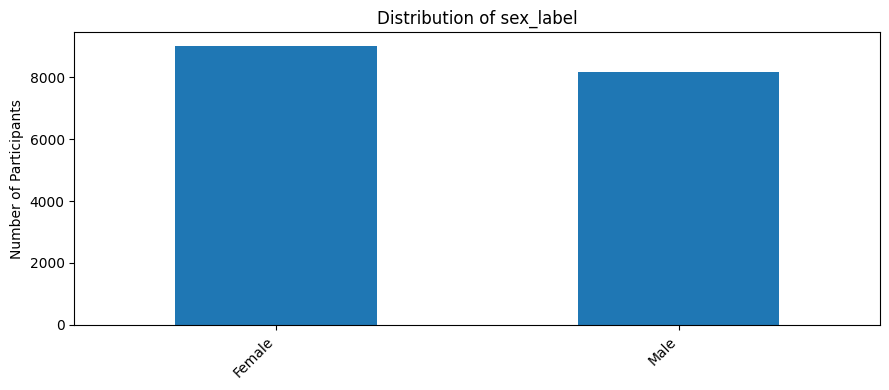

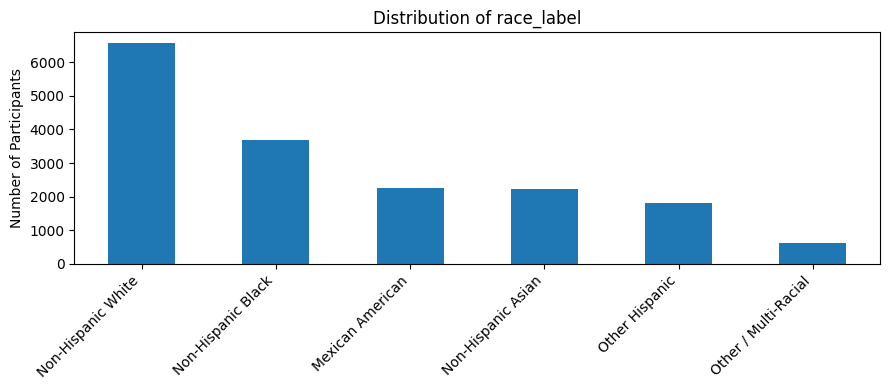

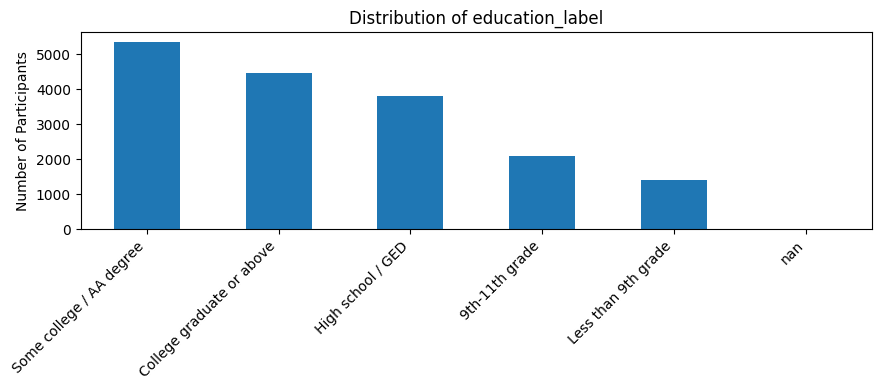

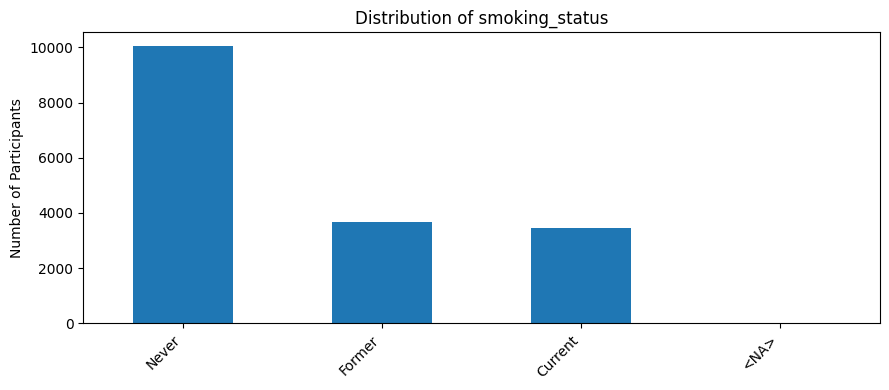

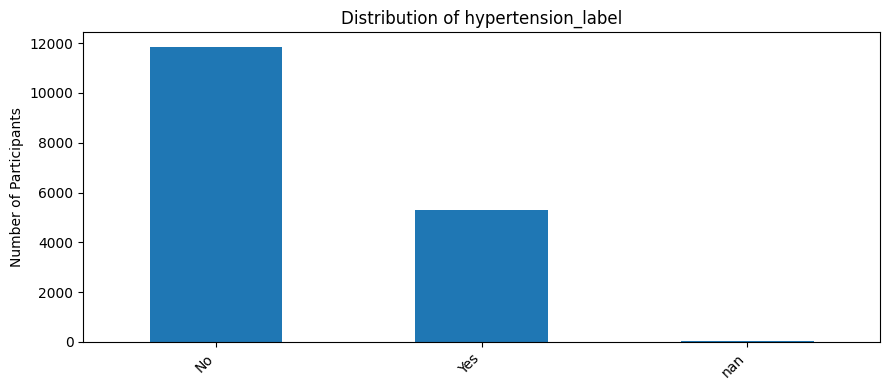

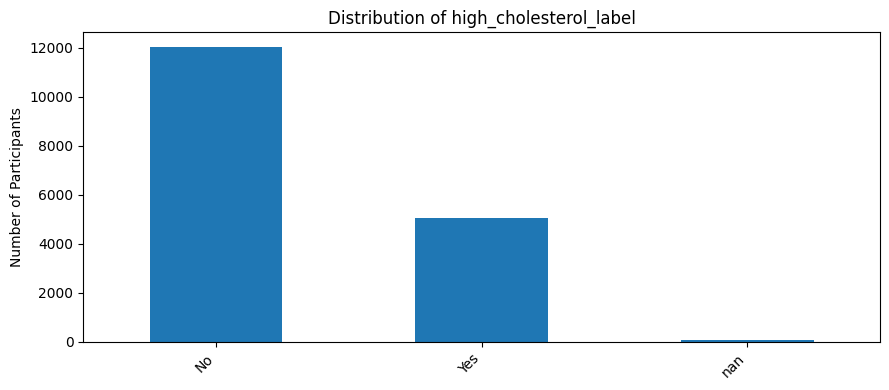

In [526]:
# Category distributions

for column in categorical_label_features:

    counts = (
        analysis_data[column]
        .value_counts(dropna=False)
    )

    plt.figure(figsize=(9, 4))

    counts.plot(kind="bar")

    plt.title(f"Distribution of {column}")
    plt.xlabel("")
    plt.ylabel("Number of Participants")

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

Sex was relatively balanced between males and females.

Race/ethnicity was more uneven, with Non-Hispanic White participants representing the largest group.

Education was concentrated primarily among participants with some college/AA education or a college degree and above.

Never smokers represented the largest smoking-status category.

Most participants reported no hypertension and no known high cholesterol, although both positive groups contained enough participants for meaningful comparison.

Missingness among the derived categorical predictors was minimal.

### Categorical Predictors vs Elevated HbA1c

The proportion of participants with elevated HbA1c is compared across categorical demographic, socioeconomic, behavioral, and health-history groups.

These comparisons are descriptive and unadjusted and should not be interpreted as causal relationships.

In [529]:
def categorical_target_summary(df, column):

    summary = (
        df.groupby(
            column,
            dropna=False
        )["elevated_hba1c"]
        .agg(
            total_participants="count",
            elevated_count="sum",
            elevated_percent="mean"
        )
    )

    summary["elevated_percent"] = (
        summary["elevated_percent"]
        * 100
    ).round(2)

    return summary

In [530]:
categorical_results = []

for column in categorical_label_features:

    summary = (
        categorical_target_summary(
            analysis_data,
            column
        )
        .reset_index()
    )

    summary = summary.rename(
        columns={column: "category"}
    )

    summary.insert(
        0,
        "variable",
        column
    )

    categorical_results.append(summary)

categorical_results = pd.concat(
    categorical_results,
    ignore_index=True
)

categorical_results

,variable,category,total_participants,elevated_count,elevated_percent
0,sex_label,Female,9000,2819,31.32
1,sex_label,Male,8156,2644,32.42
2,race_label,Mexican American,2258,754,33.39
3,race_label,Non-Hispanic Asian,2240,725,32.37
4,race_label,Non-Hispanic Black,3682,1544,41.93
5,race_label,Non-Hispanic White,6557,1681,25.64
6,race_label,Other / Multi-Racial,617,156,25.28
7,race_label,Other Hispanic,1802,603,33.46
8,education_label,9th-11th grade,2090,751,35.93
9,education_label,College graduate or above,4474,1175,26.26


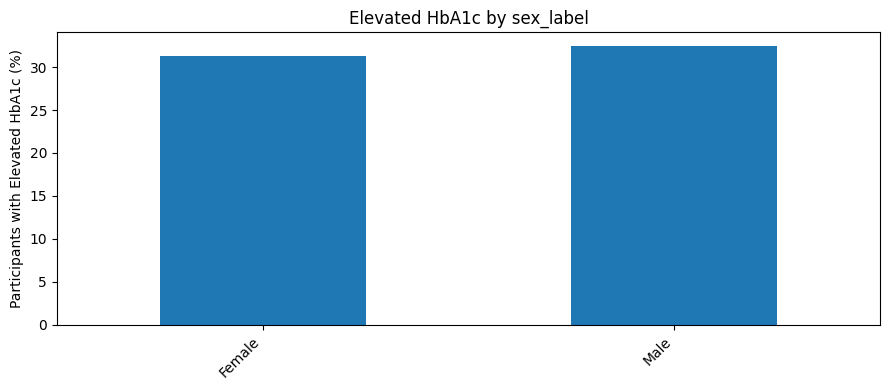

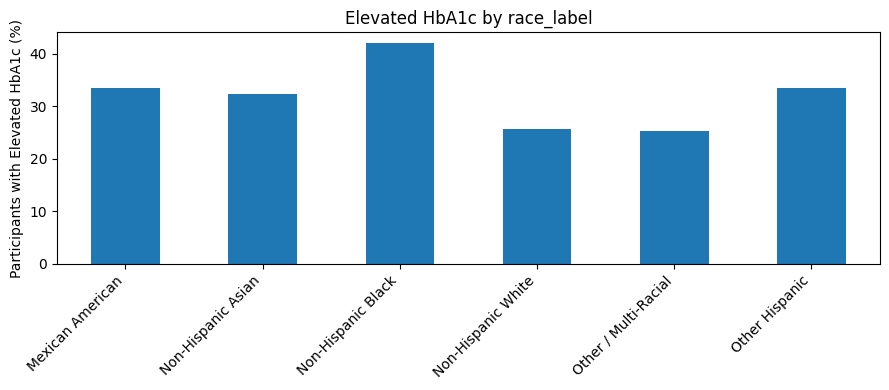

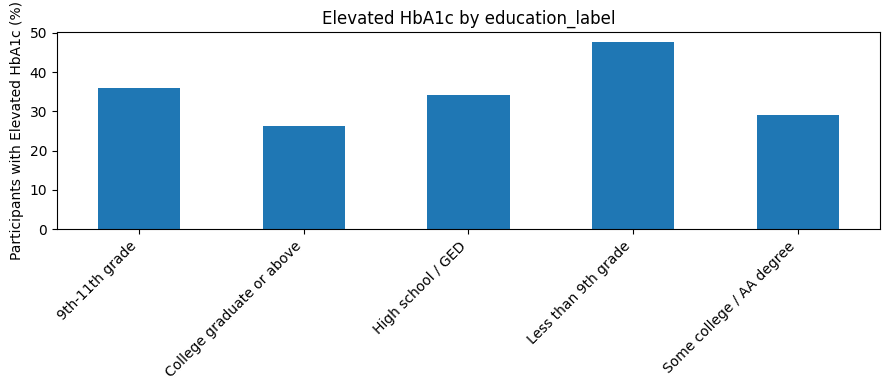

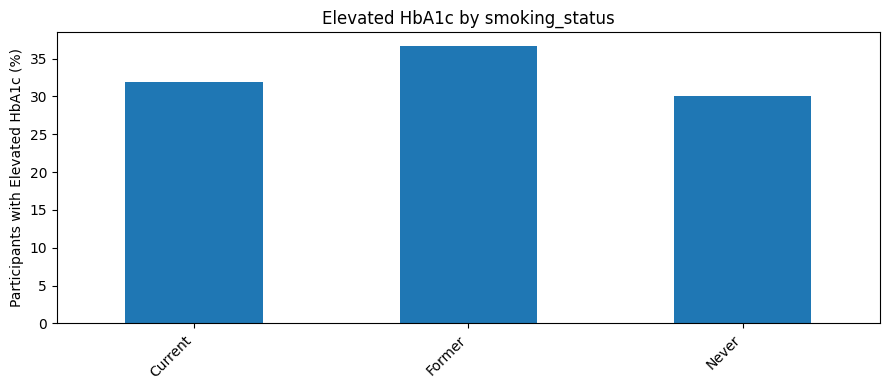

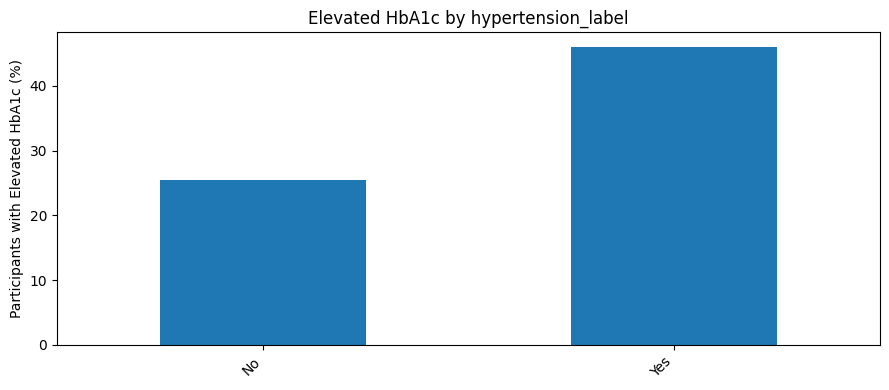

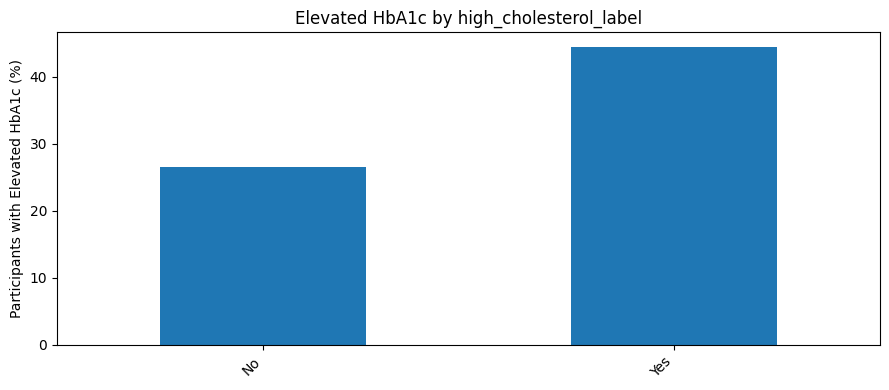

In [531]:
# Elevated HbA1c percentage by category
# Missing categories are excluded from plots

for column in categorical_label_features:

    temp = analysis_data[
        analysis_data[column].notna()
    ]

    summary = categorical_target_summary(
        temp,
        column
    )

    plt.figure(figsize=(9, 4))

    summary["elevated_percent"].plot(
        kind="bar"
    )

    plt.title(
        f"Elevated HbA1c by {column}"
    )

    plt.xlabel("")
    plt.ylabel(
        "Participants with Elevated HbA1c (%)"
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

Elevated HbA1c prevalence was similar between females and males.

Larger differences were observed across race/ethnicity and education. Non-Hispanic Black participants had a higher prevalence of elevated HbA1c than several other racial/ethnic groups, while participants with less than a 9th-grade education showed the highest prevalence among the education groups.

Former smokers had somewhat higher elevated HbA1c prevalence than current and never smokers.

Hypertension and known high cholesterol showed particularly large differences. Participants reporting either condition had substantially higher elevated HbA1c prevalence than participants who did not report the condition.

These findings are descriptive and unadjusted. Their independent predictive value will be evaluated during machine-learning modeling.

### Continuous Predictors vs Elevated HbA1c

Continuous predictors are compared between participants with normal and elevated HbA1c.
Because several variables are skewed, both means and medians are examined.

In [534]:
comparison_rows = []

for column in continuous_features:

    normal = analysis_data.loc[
        analysis_data["elevated_hba1c"] == 0,
        column
    ]

    elevated = analysis_data.loc[
        analysis_data["elevated_hba1c"] == 1,
        column
    ]

    comparison_rows.append({
        "variable": column,
        "normal_mean": normal.mean(),
        "elevated_mean": elevated.mean(),
        "normal_median": normal.median(),
        "elevated_median": elevated.median()
    })

continuous_comparison = pd.DataFrame(
    comparison_rows
)

continuous_comparison.round(2)

,variable,normal_mean,elevated_mean,normal_median,elevated_median
0,age,43.30,56.23,40.00,58.00
1,income_poverty_ratio,2.57,2.42,2.18,1.96
2,bmi,27.89,30.67,26.90,29.40
3,waist_cm,95.49,103.23,94.00,102.00
4,weight_kg,78.36,84.49,75.40,81.05
5,vigorous_minutes_week,73.08,41.68,0.00,0.00
6,moderate_minutes_week,95.79,86.03,0.00,0.00
7,recreational_activity_minutes_week,168.89,127.77,60.00,0.00
8,sedentary_minutes,373.05,358.98,360.00,300.00
9,sleep_hours,7.26,7.19,7.00,7.00


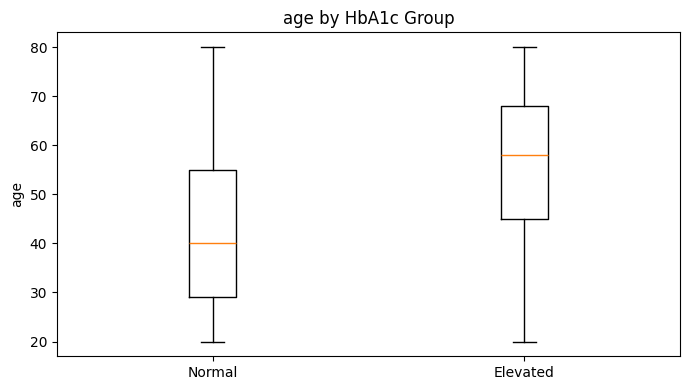

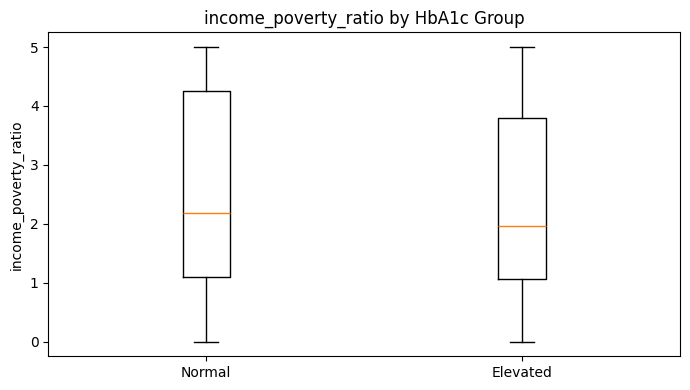

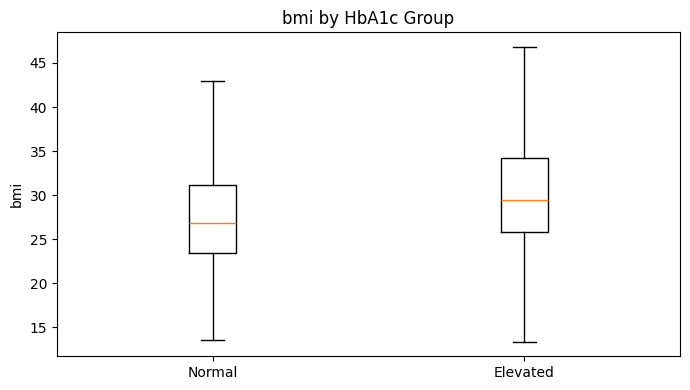

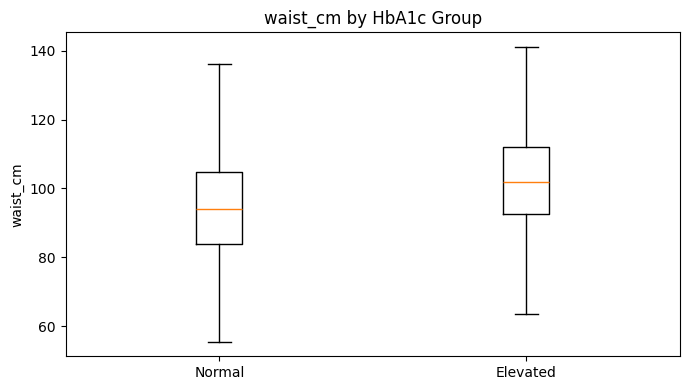

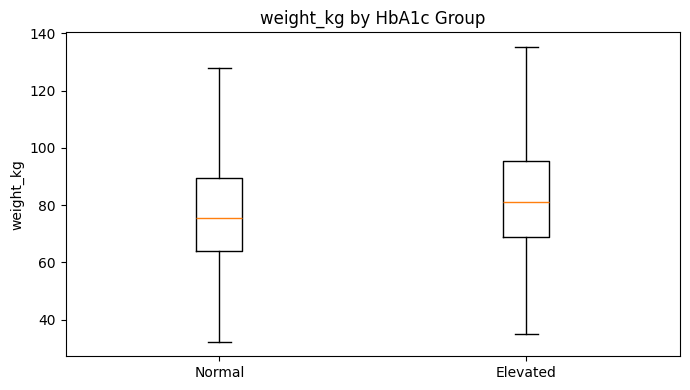

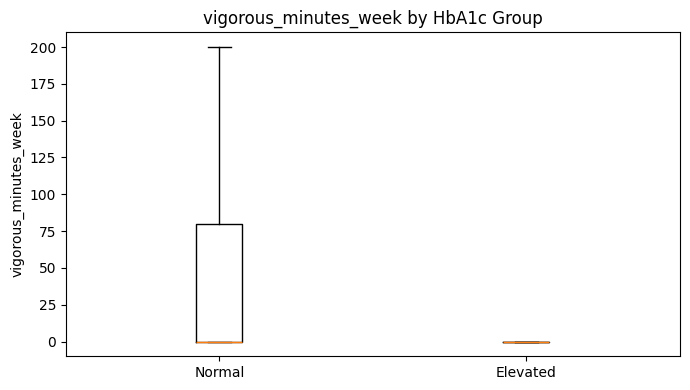

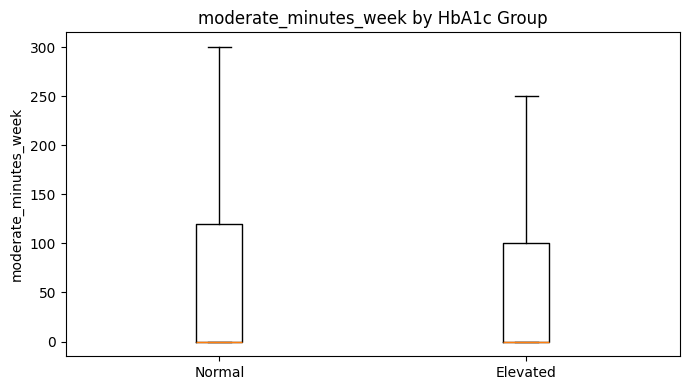

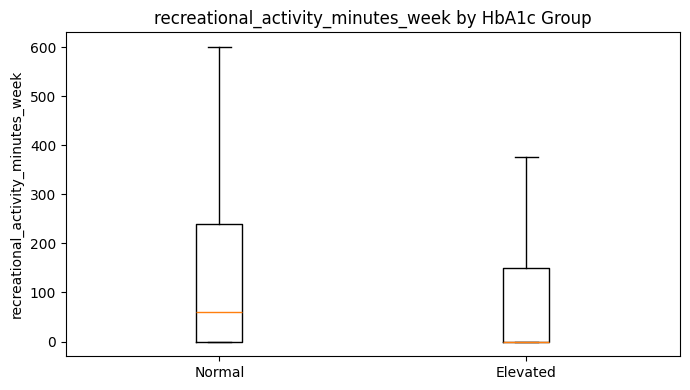

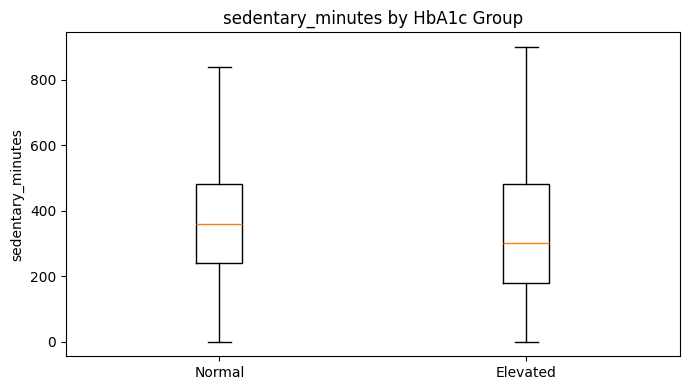

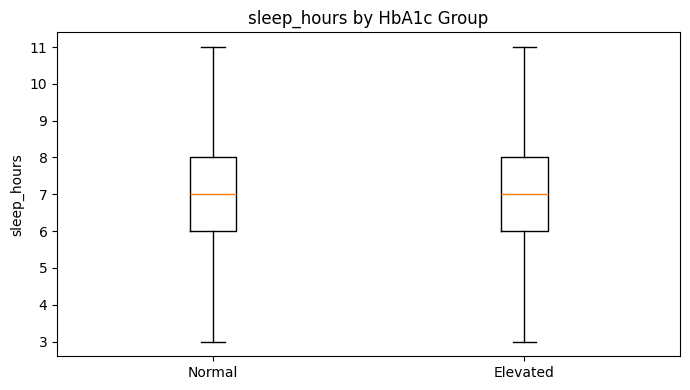

In [535]:
# Boxplots comparing normal vs elevated HbA1c

for column in continuous_features:

    normal = (
        analysis_data.loc[
            analysis_data["elevated_hba1c"] == 0,
            column
        ]
        .dropna()
    )

    elevated = (
        analysis_data.loc[
            analysis_data["elevated_hba1c"] == 1,
            column
        ]
        .dropna()
    )

    plt.figure(figsize=(7, 4))

    plt.boxplot(
        [normal, elevated],
        tick_labels=[
            "Normal",
            "Elevated"
        ],
        showfliers=False
    )

    plt.title(
        f"{column} by HbA1c Group"
    )

    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

Participants with elevated HbA1c were generally older and had higher BMI, waist circumference, and body weight than participants with normal HbA1c.

Age showed one of the clearest differences between groups.

Participants with elevated HbA1c also reported lower weekly recreational physical activity. Income-to-poverty ratio showed a smaller difference.

Sedentary time and sleep duration showed relatively little separation between the HbA1c groups.

Overall, age and anthropometric measures showed the strongest descriptive differences among the continuous predictors.

### Correlation and Redundancy Analysis

Correlation among continuous predictors is examined to identify variables that contain overlapping information.

Highly correlated predictors can introduce redundancy and multicollinearity, especially in models such as logistic regression.

Absolute correlation is used to rank relationships by strength regardless of whether the relationship is positive or negative.

In [538]:
correlation_features = [
    "age",
    "income_poverty_ratio",
    "bmi",
    "waist_cm",
    "weight_kg",
    "vigorous_minutes_week",
    "moderate_minutes_week",
    "recreational_activity_minutes_week",
    "sedentary_minutes",
    "sleep_hours"
]

pearson_corr = (
    analysis_data[correlation_features]
    .corr(method="pearson")
)

pearson_corr.round(2)

,age,income_poverty_ratio,bmi,waist_cm,weight_kg,vigorous_minutes_week,moderate_minutes_week,recreational_activity_minutes_week,sedentary_minutes,sleep_hours
age,1.00,0.08,-0.00,0.15,-0.07,-0.21,-0.04,-0.15,0.00,0.06
income_poverty_ratio,0.08,1.00,-0.07,-0.05,-0.00,0.08,0.06,0.09,0.18,-0.03
bmi,-0.00,-0.07,1.00,0.91,0.88,-0.08,-0.03,-0.07,0.06,-0.04
waist_cm,0.15,-0.05,0.91,1.00,0.89,-0.13,-0.05,-0.11,0.08,-0.02
weight_kg,-0.07,-0.00,0.88,0.89,1.00,-0.01,-0.00,-0.01,0.10,-0.07
vigorous_minutes_week,-0.21,0.08,-0.08,-0.13,-0.01,1.00,0.21,0.73,-0.03,-0.01
moderate_minutes_week,-0.04,0.06,-0.03,-0.05,-0.00,0.21,1.00,0.83,-0.06,-0.01
recreational_activity_minutes_week,-0.15,0.09,-0.07,-0.11,-0.01,0.73,0.83,1.00,-0.06,-0.01
sedentary_minutes,0.00,0.18,0.06,0.08,0.10,-0.03,-0.06,-0.06,1.00,-0.01
sleep_hours,0.06,-0.03,-0.04,-0.02,-0.07,-0.01,-0.01,-0.01,-0.01,1.00


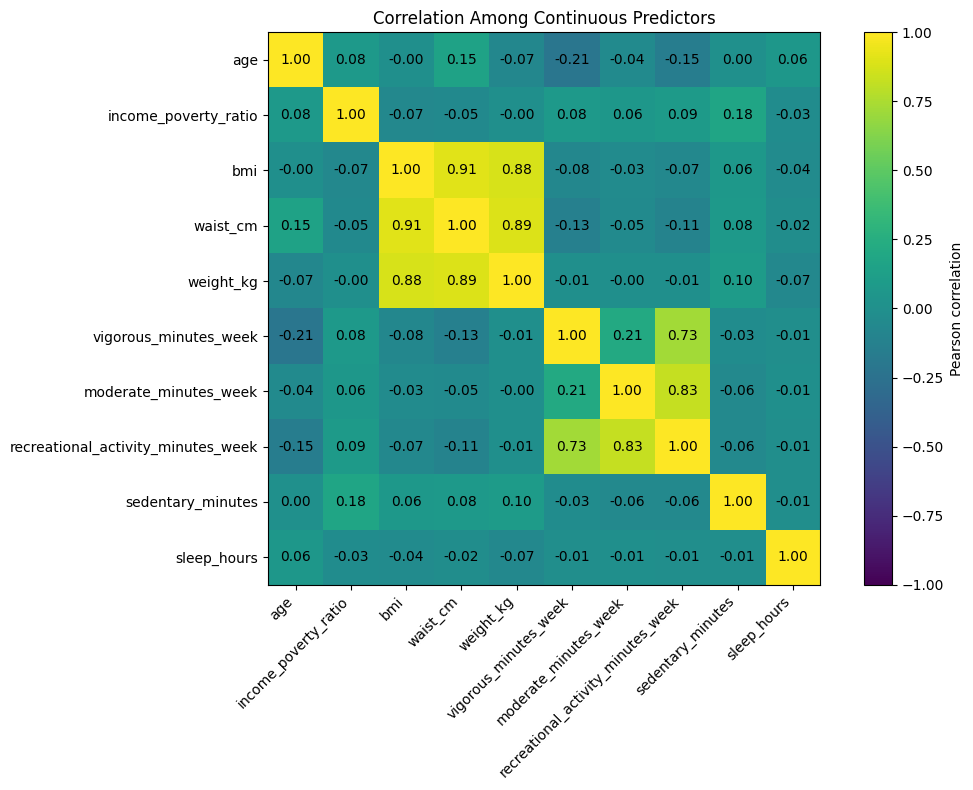

In [539]:
# Correlation heatmap

fig, ax = plt.subplots(
    figsize=(11, 8)
)

image = ax.imshow(
    pearson_corr,
    vmin=-1,
    vmax=1
)

ax.set_xticks(
    range(len(correlation_features))
)

ax.set_yticks(
    range(len(correlation_features))
)

ax.set_xticklabels(
    correlation_features,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    correlation_features
)

for i in range(
    len(correlation_features)
):
    for j in range(
        len(correlation_features)
    ):

        ax.text(
            j,
            i,
            f"{pearson_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(
    image,
    label="Pearson correlation"
)

plt.title(
    "Correlation Among Continuous Predictors"
)

plt.tight_layout()
plt.show()

In [540]:
# Rank unique correlation pairs

upper_triangle = pearson_corr.where(
    np.triu(
        np.ones(
            pearson_corr.shape
        ),
        k=1
    ).astype(bool)
)

correlation_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    "variable_1",
    "variable_2",
    "correlation"
]

correlation_pairs[
    "absolute_correlation"
] = (
    correlation_pairs[
        "correlation"
    ].abs()
)

correlation_pairs = (
    correlation_pairs
    .sort_values(
        "absolute_correlation",
        ascending=False
    )
)

correlation_pairs.head(15)

,variable_1,variable_2,correlation,absolute_correlation
17,bmi,waist_cm,0.907771,0.907771
24,waist_cm,weight_kg,0.893606,0.893606
18,bmi,weight_kg,0.882317,0.882317
39,moderate_minutes_week,recreational_activity_minutes_week,0.826526,0.826526
36,vigorous_minutes_week,recreational_activity_minutes_week,0.725352,0.725352
4,age,vigorous_minutes_week,-0.213370,0.213370
35,vigorous_minutes_week,moderate_minutes_week,0.212035,0.212035
15,income_poverty_ratio,sedentary_minutes,0.177442,0.177442
6,age,recreational_activity_minutes_week,-0.152734,0.152734
2,age,waist_cm,0.149350,0.149350


In [541]:
strong_correlations = (
    correlation_pairs[
        correlation_pairs[
            "absolute_correlation"
        ] >= 0.70
    ]
)

strong_correlations

,variable_1,variable_2,correlation,absolute_correlation
17,bmi,waist_cm,0.907771,0.907771
24,waist_cm,weight_kg,0.893606,0.893606
18,bmi,weight_kg,0.882317,0.882317
39,moderate_minutes_week,recreational_activity_minutes_week,0.826526,0.826526
36,vigorous_minutes_week,recreational_activity_minutes_week,0.725352,0.725352


BMI was very strongly correlated with waist circumference (`r ≈ 0.91`) and body weight (`r ≈ 0.88`). Waist circumference and body weight were also strongly correlated (`r ≈ 0.89`).

These findings indicate substantial overlap among the three anthropometric measures.

The physical-activity variables also showed redundancy. Total recreational activity was strongly correlated with moderate activity (`r ≈ 0.83`) and vigorous activity (`r ≈ 0.73`). This is expected because total recreational activity is derived from vigorous and moderate activity.

Most other continuous predictors showed relatively weak correlations.

Body weight will therefore not be included in the initial machine-learning predictor set. Total recreational activity will be used instead of including vigorous, moderate, and total activity simultaneously.

BMI and waist circumference will initially both be retained and their usefulness will be evaluated during model development.

### Non-Obese Subgroup Analysis

To address the fourth research question, participants with BMI below 30 kg/m² are examined separately.

The goal is to determine whether elevated HbA1c is present among adults who are not classified as obese and whether other characteristics continue to distinguish elevated-risk participants within this subgroup.

In [544]:
non_obese = analysis_data[
    analysis_data["bmi"].notna()
    & (analysis_data["bmi"] < 30)
].copy()

print(
    "Non-obese participants:",
    len(non_obese)
)

print(
    "Percent of analysis population:",
    round(
        len(non_obese)
        / len(analysis_data)
        * 100,
        2
    ),
    "%"
)

Non-obese participants: 10884
Percent of analysis population: 63.44 %


In [545]:
non_obese_target = (
    non_obese[
        "elevated_hba1c"
    ]
    .value_counts()
    .sort_index()
)

non_obese_percent = (
    non_obese[
        "elevated_hba1c"
    ]
    .value_counts(
        normalize=True
    )
    .sort_index()
    .mul(100)
    .round(2)
)

non_obese_summary = pd.DataFrame({
    "count": non_obese_target,
    "percent": non_obese_percent
})

non_obese_summary.index = [
    "Normal HbA1c",
    "Elevated HbA1c"
]

non_obese_summary

,count,percent
Normal HbA1c,7997,73.47
Elevated HbA1c,2887,26.53


In [546]:
non_obese_continuous = []

for column in continuous_features:

    normal = non_obese.loc[
        non_obese[
            "elevated_hba1c"
        ] == 0,
        column
    ]

    elevated = non_obese.loc[
        non_obese[
            "elevated_hba1c"
        ] == 1,
        column
    ]

    non_obese_continuous.append({
        "variable": column,
        "normal_mean": normal.mean(),
        "elevated_mean": elevated.mean(),
        "normal_median": normal.median(),
        "elevated_median": elevated.median()
    })

non_obese_continuous = pd.DataFrame(
    non_obese_continuous
)

non_obese_continuous.round(2)

,variable,normal_mean,elevated_mean,normal_median,elevated_median
0,age,43.40,58.69,40.00,60.00
1,income_poverty_ratio,2.63,2.50,2.29,2.06
2,bmi,24.51,25.56,24.70,26.00
3,waist_cm,88.00,92.86,88.00,93.60
4,weight_kg,69.02,70.60,68.50,70.30
5,vigorous_minutes_week,80.97,48.94,0.00,0.00
6,moderate_minutes_week,99.20,96.07,0.00,0.00
7,recreational_activity_minutes_week,180.24,145.12,60.00,0.00
8,sedentary_minutes,368.07,339.12,360.00,300.00
9,sleep_hours,7.29,7.20,7.00,7.00


In [547]:
non_obese_categorical = []

for column in categorical_label_features:

    summary = (
        categorical_target_summary(
            non_obese,
            column
        )
        .reset_index()
    )

    summary = summary.rename(
        columns={
            column: "category"
        }
    )

    summary.insert(
        0,
        "variable",
        column
    )

    non_obese_categorical.append(
        summary
    )

non_obese_categorical = pd.concat(
    non_obese_categorical,
    ignore_index=True
)

non_obese_categorical

,variable,category,total_participants,elevated_count,elevated_percent
0,sex_label,Female,5419,1334,24.62
1,sex_label,Male,5465,1553,28.42
2,race_label,Mexican American,1205,316,26.22
3,race_label,Non-Hispanic Asian,1951,585,29.98
4,race_label,Non-Hispanic Black,2027,715,35.27
5,race_label,Non-Hispanic White,4238,905,21.35
6,race_label,Other / Multi-Racial,357,56,15.69
7,race_label,Other Hispanic,1106,310,28.03
8,education_label,9th-11th grade,1297,386,29.76
9,education_label,College graduate or above,3229,706,21.86


A total of 10,884 participants, representing approximately 63.4% of the analysis population, had BMI below 30 kg/m².

Approximately 26.5% of these non-obese adults still had elevated HbA1c.

Within the non-obese subgroup, participants with elevated HbA1c were substantially older and had somewhat larger waist circumference than participants with normal HbA1c.

Elevated HbA1c also remained more common among participants with lower educational attainment, hypertension, and known high cholesterol. Recreational physical activity was generally lower in the elevated HbA1c group.

These findings suggest that elevated glycemic risk is not limited to adults with obesity and that additional demographic, behavioral, socioeconomic, and health-history characteristics may help identify higher-risk adults.

### Summary of EDA Findings

he final analysis population contained 17,156 adults without previously reported diabetes. Approximately 31.8% had elevated HbA1c.

Age and anthropometric measures showed some of the clearest differences between participants with normal and elevated HbA1c. Participants with elevated HbA1c were generally older and had higher BMI, waist circumference, and body weight.

Elevated HbA1c prevalence also differed across race/ethnicity, education, hypertension, and known high-cholesterol groups. Hypertension and high cholesterol showed particularly noticeable differences.

Recreational physical activity was generally lower among participants with elevated HbA1c, while sleep duration and sedentary time showed relatively small unadjusted differences.

Correlation analysis identified substantial redundancy among BMI, waist circumference, and body weight. The recreational activity variables were also related because total recreational activity is derived from vigorous and moderate activity.

Importantly, approximately 26.5% of adults with BMI below 30 kg/m² still had elevated HbA1c. This indicates that elevated glycemic risk is not limited to adults with obesity.

Overall, the EDA suggests that elevated HbA1c is associated with a combination of demographic, anthropometric, socioeconomic, behavioral, and health-history characteristics.

### Predictor Selection for Machine Learning

The initial candidate predictor set includes demographic, socioeconomic, anthropometric, behavioral, and health-history characteristics.

Body weight is excluded because it is highly correlated with BMI and waist circumference.

Total recreational activity is retained instead of including vigorous activity, moderate activity, and total recreational activity together.

BMI and waist circumference are initially retained because they represent related but different measures of body composition. Their contribution will be evaluated during model development.

The original HbA1c measurement is not included because it was used to construct the target and would cause target leakage.

Participant identifiers, diabetes eligibility variables, and NHANES survey-design variables are also excluded from the machine-learning predictor set.


In [551]:
# Predictors
numeric_features = [
    "age",
    "income_poverty_ratio",
    "bmi",
    "waist_cm",
    "recreational_activity_minutes_week",
    "sedentary_minutes",
    "sleep_hours"
]

categorical_features = [
    "sex",
    "race_ethnicity",
    "education",
    "smoking_status",
    "hypertension",
    "high_cholesterol"
]

target = "elevated_hba1c"

model_features = (
    numeric_features
    + categorical_features
)

In [552]:
print(
    "Number of candidate predictors:",
    len(model_features)
)

print("\nNumeric predictors:")
for feature in numeric_features:
    print("-", feature)

print("\nCategorical predictors:")
for feature in categorical_features:
    print("-", feature)

Number of candidate predictors: 13

Numeric predictors:
- age
- income_poverty_ratio
- bmi
- waist_cm
- recreational_activity_minutes_week
- sedentary_minutes
- sleep_hours

Categorical predictors:
- sex
- race_ethnicity
- education
- smoking_status
- hypertension
- high_cholesterol


In [553]:
X = analysis_data[
    model_features
].copy()

y = analysis_data[
    target
].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (17156, 13)
y shape: (17156,)


In [554]:
#veryfying target
print(
    y.value_counts()
)

print(
    "\nTarget percentages:"
)

print(
    y.value_counts(
        normalize=True
    )
    .mul(100)
    .round(2)
)

elevated_hba1c
0    11693
1     5463
Name: count, dtype: int64

Target percentages:
elevated_hba1c
0    68.16
1    31.84
Name: proportion, dtype: float64


In [555]:
# final missing check in Predictor set
model_missingness = pd.DataFrame({
    "missing_count": X.isna().sum(),
    "missing_percent": (
        X.isna().mean()
        * 100
    ).round(2)
})

model_missingness = (
    model_missingness
    .sort_values(
        "missing_percent",
        ascending=False
    )
)

model_missingness

,missing_count,missing_percent
income_poverty_ratio,1629,9.50
waist_cm,816,4.76
bmi,193,1.12
sedentary_minutes,109,0.64
high_cholesterol,78,0.45
sleep_hours,60,0.35
recreational_activity_minutes_week,25,0.15
hypertension,18,0.10
smoking_status,14,0.08
education,13,0.08


### Final Candidate Predictor Set

The machine-learning dataset contains 13 candidate predictors:

**Demographic**
- Age
- Sex
- Race/ethnicity

**Socioeconomic**
- Education
- Income-to-poverty ratio

**Anthropometric**
- BMI
- Waist circumference

**Behavioral**
- Recreational activity minutes per week
- Sedentary minutes
- Smoking status
- Sleep duration

**Health History**
- Hypertension
- Known high cholesterol

Missing values will be handled within the machine-learning preprocessing pipeline rather than before the train/test split.

### Variables Excluded from Modeling

The following variables will not be used as direct machine-learning predictors:

- `SEQN` — participant identifier
- `hba1c` — used to construct the target; including it would cause target leakage
- `diabetes_report` — used to define study eligibility
- `mec_weight`, `psu`, `stratum` — NHANES survey-design variables rather than participant risk factors
- `cycle` — survey-cycle identifier
- `weight_kg` — highly redundant with BMI and waist circumference
- `vigorous_minutes_week` and `moderate_minutes_week` — replaced by total recreational activity for the initial model
- raw activity questionnaire variables — replaced by derived weekly activity measures
- `smoked_100_cigarettes` and `current_smoking` — replaced by the derived `smoking_status`

### Planned Feature-Set Comparison

Two predictor sets will be compared during modeling.

A simple baseline feature set will use age and BMI.

The expanded feature set will add demographic, socioeconomic, anthropometric, behavioral, and health-history characteristics.

This comparison will help determine whether additional non-laboratory characteristics improve prediction beyond age and BMI alone.

In [559]:
baseline_features = [
    "age",
    "bmi"
]

expanded_features = model_features.copy()

print(
    "Baseline predictors:",
    baseline_features
)

print(
    "\nExpanded predictors:",
    expanded_features
)

Baseline predictors: ['age', 'bmi']

Expanded predictors: ['age', 'income_poverty_ratio', 'bmi', 'waist_cm', 'recreational_activity_minutes_week', 'sedentary_minutes', 'sleep_hours', 'sex', 'race_ethnicity', 'education', 'smoking_status', 'hypertension', 'high_cholesterol']
